<a href="https://colab.research.google.com/github/Nosimon-Nahar/LabReport-2_CSE-418/blob/main/Bersenham'sCircle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import matplotlib.pyplot as plt

In [2]:
def bresenham_circle(xc, yc, r):
    points = []
    x = 0
    y = r
    p = 3 - 2 * r  # initial decision parameter

    def plot_octants(x, y):
        # Use symmetry to plot all 8 octants at once
        points.extend([
            (xc + x, yc + y),
            (xc - x, yc + y),
            (xc + x, yc - y),
            (xc - x, yc - y),
            (xc + y, yc + x),
            (xc - y, yc + x),
            (xc + y, yc - x),
            (xc - y, yc - x),
        ])

    plot_octants(x, y)

    while x < y:
        x += 1
        if p < 0:
            p += 4 * x + 6
        else:
            y -= 1
            p += 4 * (x - y) + 10
        plot_octants(x, y)

    # Remove duplicate points (they occur at x=0 and at x=y, where
    # the mirrored/swapped octant coordinates coincide) while preserving order
    points = list(dict.fromkeys(points))

    return points


def split_by_quadrant(points, xc, yc):
    """
    Split circle points into the 4 quadrants relative to the center (xc, yc):
    Q1: x >= xc, y >= yc
    Q2: x <  xc, y >= yc
    Q3: x <  xc, y <  yc
    Q4: x >= xc, y <  yc
    """
    q1, q2, q3, q4 = [], [], [], []
    for x, y in points:
        if x >= xc and y >= yc:
            q1.append((x, y))
        elif x < xc and y >= yc:
            q2.append((x, y))
        elif x < xc and y < yc:
            q3.append((x, y))
        else:
            q4.append((x, y))
    return q1, q2, q3, q4


def order_points_by_angle(points, xc, yc):
    """Sort points by angle around the center so a line can trace the circle in order."""
    return sorted(points, key=lambda p: math.atan2(p[1] - yc, p[0] - xc))

Enter x center: 0
Enter y center: 0
Enter radius: 6

 ---Bresenham's (Midpoint) Circle Drawing Algorithm--- 
Center point: (0,0)
Radius:  6

Quadrant 1 (x >= xc, y >= yc):
[(0, 6), (6, 0), (1, 6), (6, 1), (2, 5), (5, 2), (3, 5), (5, 3), (4, 4)]

Quadrant 2 (x < xc, y >= yc):
[(-6, 0), (-1, 6), (-6, 1), (-2, 5), (-5, 2), (-3, 5), (-5, 3), (-4, 4)]

Quadrant 3 (x < xc, y < yc):
[(-1, -6), (-6, -1), (-2, -5), (-5, -2), (-3, -5), (-5, -3), (-4, -4)]

Quadrant 4 (x >= xc, y < yc):
[(0, -6), (1, -6), (6, -1), (2, -5), (5, -2), (3, -5), (5, -3), (4, -4)]


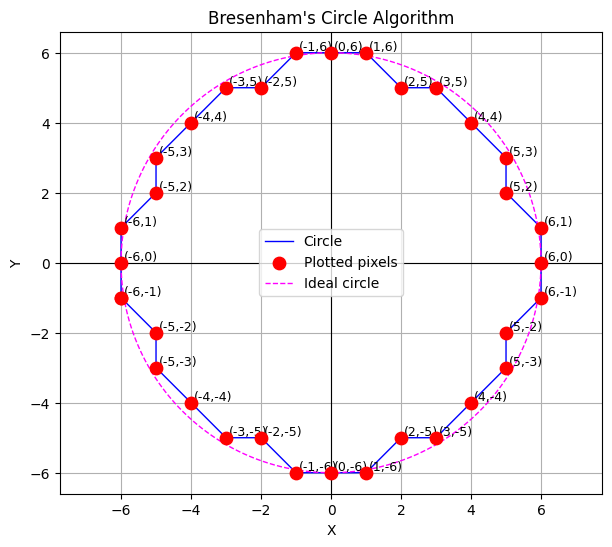

In [3]:
def plot_bresenham_circle(xc, yc, r):
    points = bresenham_circle(xc, yc, r)
    ordered = order_points_by_angle(points, xc, yc)
    # Close the loop by returning to the first point
    ordered.append(ordered[0])

    xs = [p[0] for p in ordered]
    ys = [p[1] for p in ordered]

    plt.figure(figsize=(7, 6))

    plt.plot(xs, ys, color="blue", linewidth=1, label="Circle")
    # Line joining the plotted pixels, in order around the circle
    plt.scatter(xs, ys, color="red", s=80, zorder=6, label="Plotted pixels")

    # line in X and Y axis
    plt.axhline(y=yc, color="black", linewidth=0.8)
    plt.axvline(x=xc, color="black", linewidth=0.8)

    # Ideal mathematical circle for comparison
    theta = [i * 0.01 for i in range(629)]  # 0 to 2*pi
    ideal_x = [xc + r * math.cos(t) for t in theta]
    ideal_y = [yc + r * math.sin(t) for t in theta]
    plt.plot(ideal_x, ideal_y, color="magenta", linestyle="--", linewidth=1, label="Ideal circle")
    for x,y in points: # Text annotation (Coordinates)
     plt.text(x + 0.08, y + 0.08, f"({x},{y})", fontsize=9)

    plt.title("Bresenham's Circle Algorithm")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.show()


if __name__ == "__main__":
    xc= int(input("Enter x center: "))
    yc = int(input("Enter y center: "))
    r = int(input("Enter radius: "))

    print("\n ---Bresenham's (Midpoint) Circle Drawing Algorithm--- ")
    print(f"Center point: ({xc},{yc})")
    print("Radius: ",r)

    all_points = bresenham_circle(xc, yc, r)
    q1, q2, q3, q4 = split_by_quadrant(all_points, xc, yc)

    print("\nQuadrant 1 (x >= xc, y >= yc):")
    print(q1)
    print("\nQuadrant 2 (x < xc, y >= yc):")
    print(q2)
    print("\nQuadrant 3 (x < xc, y < yc):")
    print(q3)
    print("\nQuadrant 4 (x >= xc, y < yc):")
    print(q4)

    plot_bresenham_circle(xc, yc, r)